In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss


In [3]:
def read_lod_file(path):
    text = path.read_text(encoding="utf-8-sig")
    lines = [line.strip() for line in text.splitlines() if line.strip()]

    decimal_comma = all(";" not in line and line.count(",") == 1 for line in lines[:20])
    if decimal_comma:
        values = pd.Series([float(line.replace(",", ".")) for line in lines])
        return pd.DataFrame({"LOD": values})

    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)

    return pd.read_csv(path, sep=None, engine="python")


path = Path("data/LOD.csv")
data = read_lod_file(path)
data.head()


,LOD
0,0.505752
1,0.477329
2,0.445725
3,0.410404
4,0.415962


In [4]:
def parse_date_column(values):
    text = values.astype(str).str.strip()

    parsed = pd.to_datetime(text, format="%Y%m%d", errors="coerce")
    if parsed.notna().mean() > 0.7:
        return parsed

    return pd.to_datetime(values, errors="coerce")


def prepare_lod_series(data):
    df = data.copy()
    df.columns = [str(col).strip() for col in df.columns]

    date_col = None
    for col in df.columns:
        low = col.lower()
        if any(word in low for word in ["date", "дата", "time", "mjd", "year"]):
            parsed = parse_date_column(df[col])
            if parsed.notna().mean() > 0.7:
                date_col = col
                df[col] = parsed
                break

    numeric = df.apply(pd.to_numeric, errors="coerce")
    numeric_cols = [col for col in numeric.columns if numeric[col].notna().sum() > 10]

    value_col = None
    for col in numeric_cols:
        low = str(col).lower()
        if any(word in low for word in ["lod", "value", "вариац", "speed", "скор"]):
            value_col = col
            break

    if value_col is None:
        value_col = numeric[numeric_cols].var(numeric_only=True).idxmax()

    series = numeric[value_col].dropna().astype(float)

    if date_col is not None:
        series.index = df.loc[series.index, date_col]
        series = series.sort_index()
        series = series[~series.index.duplicated(keep="first")]

    return series, value_col


lod, value_col = prepare_lod_series(data)

print(f"Файл: {path}")
print(f"Столбец ряда: {value_col}")
print(f"Длина ряда: {len(lod)}")
print(f"Среднее: {lod.mean():.6f}")
print(f"Стандартное отклонение: {lod.std():.6f}")


Файл: data\LOD.csv
Столбец ряда: LOD
Длина ряда: 725
Среднее: 0.424382
Стандартное отклонение: 0.210257


In [5]:
def infer_period(series):
    if isinstance(series.index, pd.DatetimeIndex) and len(series) > 3:
        days = np.diff(series.index.view("int64")) / 1e9 / 86400
        step = np.nanmedian(days)

        if step <= 2:
            return min(365, max(2, len(series) // 3))
        if step <= 10:
            return min(52, max(2, len(series) // 3))
        if step <= 35:
            return min(12, max(2, len(series) // 3))

    if len(series) >= 600:
        return 365
    if len(series) >= 120:
        return 12

    return max(2, min(12, len(series) // 4))


period = infer_period(lod)
stl = STL(lod, period=period, robust=True).fit()

trend = stl.trend
seasonal = stl.seasonal
remainder = stl.resid
cycle_window = min(max(period // 2, 7), max(7, len(lod) // 5))

cyclic = remainder.rolling(cycle_window, center=True, min_periods=max(3, cycle_window // 2)).mean()
stationary_residue = (remainder - cyclic).dropna()

print(f"Период сезонности: {period}")
print(f"Окно для циклической составляющей: {cycle_window}")
print(f"Длина стационарного остатка: {len(stationary_residue)}")


Период сезонности: 365
Окно для циклической составляющей: 145
Длина стационарного остатка: 725


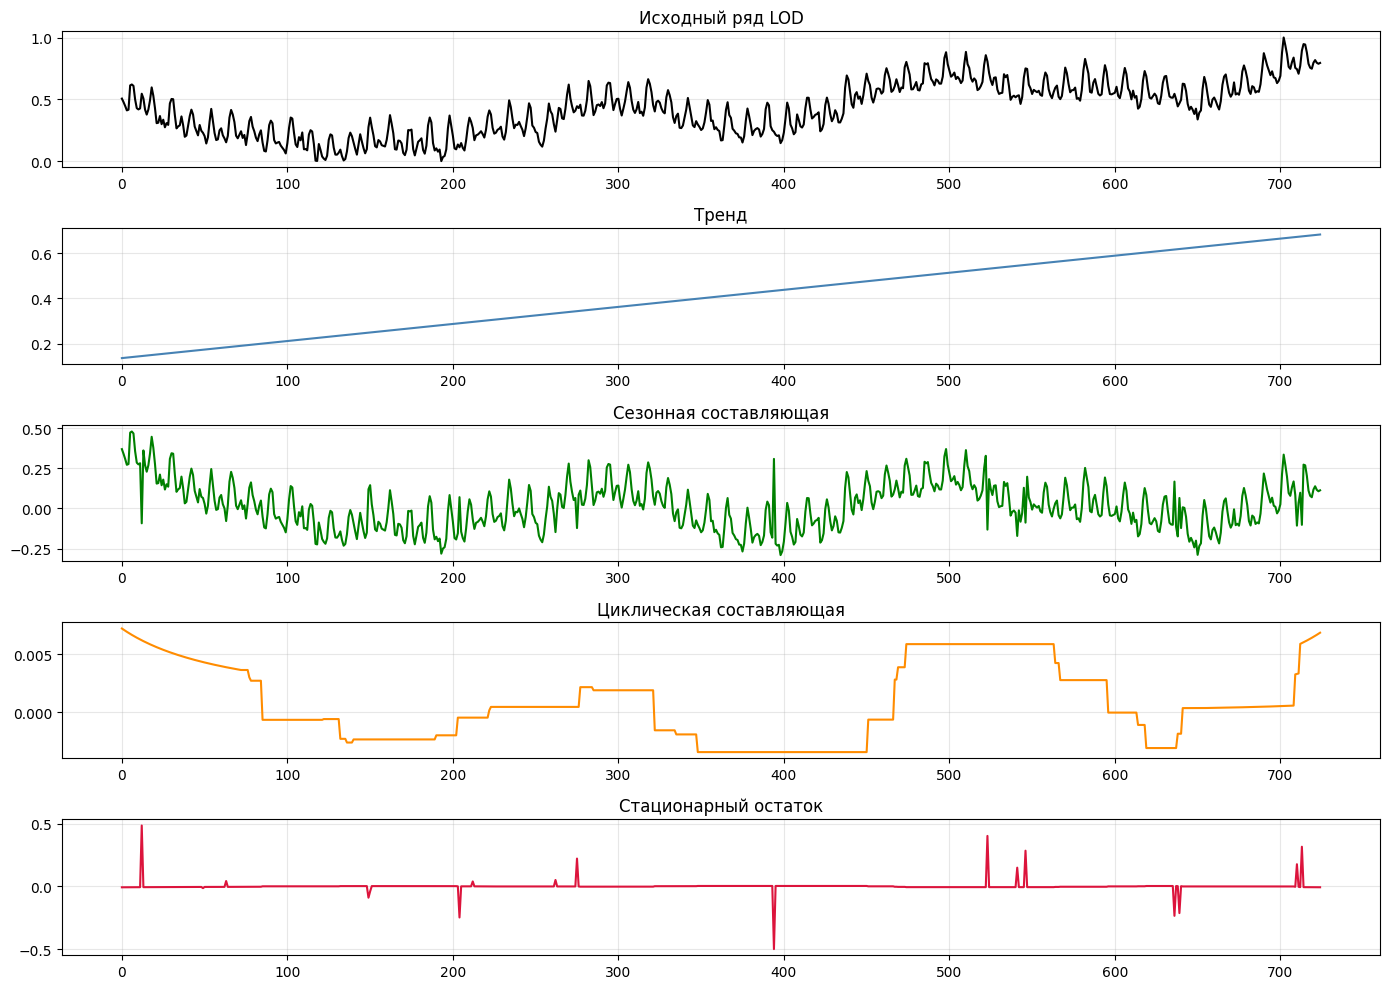

In [6]:
plt.figure(figsize=(14, 10))

plt.subplot(5, 1, 1)
plt.plot(lod, color="black")
plt.title("Исходный ряд LOD")
plt.grid(True, alpha=0.3)

plt.subplot(5, 1, 2)
plt.plot(trend, color="steelblue")
plt.title("Тренд")
plt.grid(True, alpha=0.3)

plt.subplot(5, 1, 3)
plt.plot(seasonal, color="green")
plt.title("Сезонная составляющая")
plt.grid(True, alpha=0.3)

plt.subplot(5, 1, 4)
plt.plot(cyclic, color="darkorange")
plt.title("Циклическая составляющая")
plt.grid(True, alpha=0.3)

plt.subplot(5, 1, 5)
plt.plot(stationary_residue, color="crimson")
plt.title("Стационарный остаток")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
adf_stat, adf_pvalue, _, _, adf_crit, _ = adfuller(stationary_residue, autolag="AIC")
kpss_stat, kpss_pvalue, _, kpss_crit = kpss(stationary_residue, regression="c", nlags="auto")

print("ADF-тест")
print(f"Статистика: {adf_stat:.4f}")
print(f"p-value: {adf_pvalue:.4f}")
print(f"Критические значения: {adf_crit}")
print()
print("KPSS-тест")
print(f"Статистика: {kpss_stat:.4f}")
print(f"p-value: {kpss_pvalue:.4f}")
print(f"Критические значения: {kpss_crit}")


ADF-тест
Статистика: -14.5317
p-value: 0.0000
Критические значения: {'1%': np.float64(-3.439439614524914), '5%': np.float64(-2.865551414233055), '10%': np.float64(-2.5689061365397747)}

KPSS-тест
Статистика: 0.0328
p-value: 0.1000
Критические значения: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\vadin\AppData\Local\Temp\ipykernel_8644\2435375117.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, _, kpss_crit = kpss(stationary_residue, regression="c", nlags="auto")


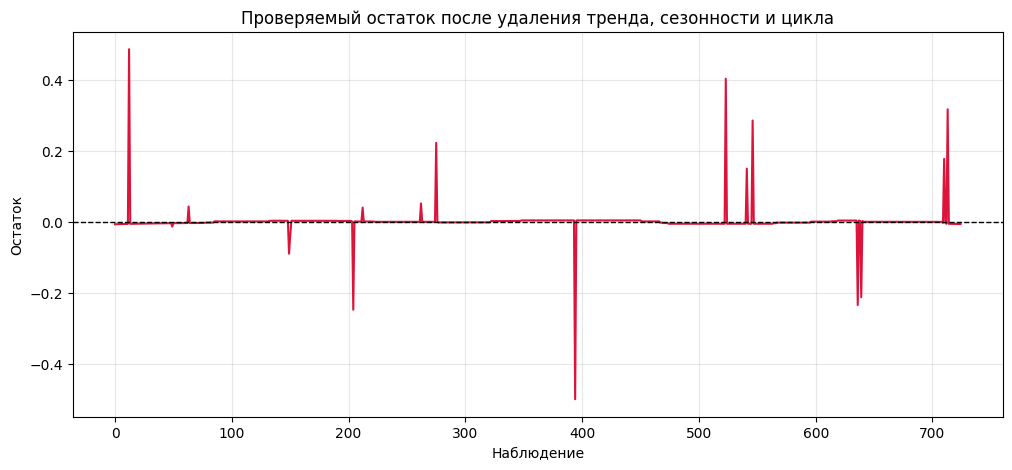

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(stationary_residue, color="crimson")
plt.axhline(stationary_residue.mean(), color="black", linestyle="--", linewidth=1)
plt.title("Проверяемый остаток после удаления тренда, сезонности и цикла")
plt.xlabel("Наблюдение")
plt.ylabel("Остаток")
plt.grid(True, alpha=0.3)
plt.show()


## Выводы

Ряд LOD разложен на тренд, сезонную составляющую, циклическую составляющую и остаток.

Тренд показывает медленное изменение среднего уровня ряда. Сезонная составляющая описывает регулярные колебания. Циклическая составляющая выделена сглаживанием остатка после удаления тренда и сезонности.

Стационарность итогового остатка проверяется двумя тестами. В ADF-тесте малая p-value говорит в пользу стационарности. В KPSS-тесте малая p-value, наоборот, говорит против стационарности. Поэтому остаток можно считать стационарным, если ADF отвергает наличие единичного корня, а KPSS не отвергает стационарность.
